<a href="https://colab.research.google.com/github/Nurdaylight/A-Karpathy-repl/blob/main/12_01_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [340]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [341]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"
filename = 'names.txt'

with urllib.request.urlopen(url) as f:
    data = f.read().decode("utf-8")

words= data.splitlines()


In [342]:
chars=sorted(set(".".join(words)))
stoi={j:i for i,j in enumerate(chars)}
itos={i:j for i,j in enumerate(chars)}
print(chars)
stoi["."]

['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


0

In [343]:
context=4
words=["."*context+word+"."for word in words]

In [345]:
import random

random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
X_tr=[word[i:i+context] for word in words[:n1] for i in range(0,len(word)-context)]
X_dev=[word[i:i+context] for word in words[n1:n2] for i in range(0,len(word)-context)]
X_test=[word[i:i+context] for word in words[n2:] for i in range(0,len(word)-context)]

X_tr=[stoi[x] for val in X_tr for x in val]
X_dev=[stoi[x] for val in X_dev for x in val]
X_test=[stoi[x] for val in X_test for x in val]

X_tr=torch.tensor(X_tr).reshape(-1,4)
X_dev=torch.tensor(X_dev).reshape(-1,4)
X_test=torch.tensor(X_test).reshape(-1,4)

Y_tr=[stoi[word[i+context]] for word in words  for i in range(0,len(word)-context)]
Y_dev=[stoi[word[i+context]] for word in words[n1:n2]  for i in range(0,len(word)-context)]
Y_test=[stoi[word[i+context]] for word in words[n2:]  for i in range(0,len(word)-context)]
Y_tr=torch.tensor(Y_tr)
Y_dev=torch.tensor(Y_dev)
Y_test=torch.tensor(Y_test)

In [346]:
#dont think below is necessary looking back

#Make mappings of context of 3 to next predicted letter. For each word. Aka data X and data Y.
#lets replace whole data with numbers
num_words=[stoi[i] for word in words for i in word]
num_words[:5]

[0, 0, 0, 0, 5]

In [118]:
X_str=[word[i:i+context] for word in words for i in range(0,len(word)-context)]
Y=[stoi[word[i+context]] for word in words  for i in range(0,len(word)-context)]

X=[stoi[x] for val in X_str for x in val]
X=torch.tensor(X).reshape(-1,4)
Y=torch.tensor(Y)


In [16]:
#made respectable

In [378]:
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,5),generator=g)
W1=torch.randn((20,200),generator=g)*0.1
b1=torch.randn((200),generator=g)*0.1
W2=torch.randn((200,27),generator=g)*0.1
b2=torch.randn((27),generator=g)*0.1
parameters=[C, W1,b1,W2,b2]

In [380]:
for p in parameters:
  p.requires_grad=True

In [381]:
lrs=torch.linspace(-3,0,1000)
lrs=10**lrs
lossi=[]

In [388]:
for i in range (500):
  id=torch.randint(0, len(X_tr), (32,), generator=g)
  emb=C[X_tr[id]]
  h=torch.tanh(emb.view(-1,20)@W1 +b1)
  logits=h@W2+b2
  loss = F.cross_entropy(logits,Y_tr[id])

  for p in parameters:
    p.grad=None #Clearing gradients
  loss.backward()

  lr=-0.1 if i < 20000 else -0.01
  for p in parameters:
    p.data+= lr*p.grad
#  lossi.append(loss.item())
print(loss.item())

1.8076434135437012


In [383]:
C[X].shape

torch.Size([228146, 3, 5])

In [391]:
#Total loss
emb=C[X_test]
h=torch.tanh(emb.view(-1,20)@W1 +b1)
logits=h@W2+b2
loss=F.cross_entropy(logits, Y_test)
loss.item()

2.1638972759246826

In [136]:
torch.randint(0, len(X), (1, 32), generator=g).view(-1)

tensor([ 49774, 201075, 212273, 187393,  20354,  63832,  22730, 107031, 164006,
        205346, 126142, 163533, 133320, 125742,  15934, 146878,  44727, 138516,
        156645, 214811, 225830, 166871, 123348,  91466,  54705, 103478, 151030,
        177184, 206696,  81496,   3489, 119286])

In [329]:
C[[1,5,9, 15, 21,23, 25]]

tensor([[ 1.0419,  2.7009,  1.0727],
        [ 2.3971,  2.2316, -1.9110],
        [ 1.2576,  1.1303, -1.6264],
        [ 1.2231,  1.8405, -0.3131],
        [ 0.3619,  1.1472,  0.5233],
        [-0.6098,  0.1186, -0.6396],
        [ 0.6616,  0.3589, -2.7469]], grad_fn=<IndexBackward0>)

In [331]:
C[[2,3,4,6,24,26]]

tensor([[-0.9079,  0.2136,  1.4104],
        [ 0.3773, -1.4074,  0.5369],
        [-0.7262, -0.5641,  1.1554],
        [-0.2234, -0.8834,  0.7558],
        [ 0.2527, -0.0987, -1.4294],
        [-1.3586, -0.0287, -0.6197]], grad_fn=<IndexBackward0>)

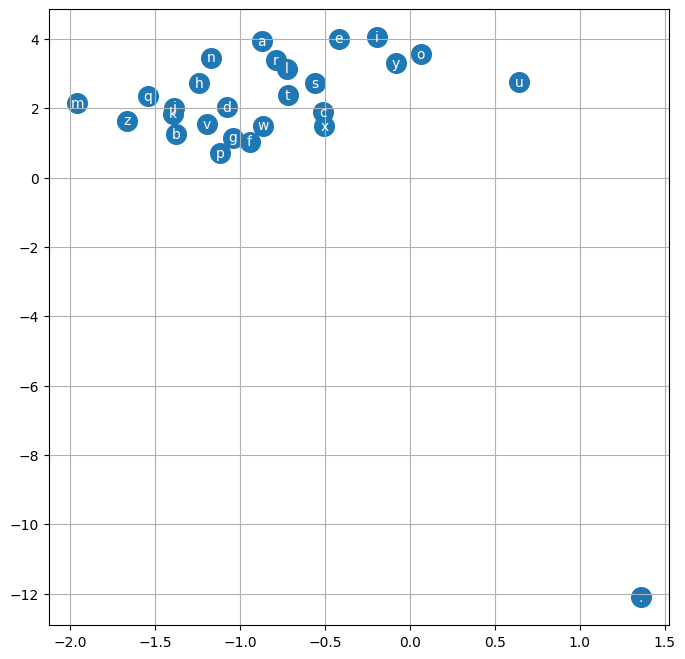

In [362]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [385]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * 4 # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmah.
amille.
khismi.
xhelly.
salaysa.
jazhnel.
deniya.
jareei.
nerisia.
chaiiv.
kaleigh.
ham.
joci.
quinn.
suline.
livabi.
watthon.
jaryni.
jaceuni.
saylen.
